# Vector Autoregression with Hyper-Trees

This walkthrough introduces the multivariate Hyper-Tree models. They extend the autoregressive Hyper-Trees to a VAR(p) target model over an aligned panel of k series:

$$y_{i,t} = \sum_{j=1}^{p} A_j[i, :](x_{i,t}) \cdot y_{t-j}$$

Every series' forecast is a feature-dependent linear combination of the lagged values of *all* series, so cross-series lead/lag dependence is captured by the off-diagonal coefficients of the time-varying lag matrices.

- **`HyperTreeNetVAR`** (GBDT encoder + MLP decoder): the boosting cost is independent of the number of coefficients. This is the **strongly recommended** variant.
- **`HyperTreeVAR`** (one boosted tree per coefficient): fully interpretable and intended for small panels, since each boosting round grows `k * p` trees.
- **`type="factor"`** (restricted "Global VAR", available on both models): each equation keeps only its own lags plus a shared cross-sectional factor, so the coefficient count per equation is `2 * p` regardless of k. This makes it a scalable middle ground when the unrestricted VAR is over-parameterized.

All models require an *aligned panel*: all series must have the same length and identical dates.

In [1]:
import numpy as np
import pandas as pd
import torch

from hypertrees import ForecastIntervals
from hypertrees.models import HyperTreeAR
from hypertrees.models.HyperTreeVAR import HyperTreeVAR
from hypertrees.models.HyperTreeNetVAR import HyperTreeNetVAR
from utils import calculate_metrics, plot_panel_forecasts, simulate_var_panel

device = "cuda" if torch.cuda.is_available() else "cpu"

# Shared setup, used by all models
seed = 123
num_iterations = 300
level = [80]
forecast_intervals = ForecastIntervals(
    n_windows=10,                       # number of rolling calibration windows
    method="conformal_distribution",    # or "conformal_error"
    step_size=1,                        # time steps between windows
    refit=False,                        # train once on the oldest window for speed
)

## Simulate an Aligned Panel

We simulate 10 monthly series over 20 years from a stable VAR(1) with a lead/lag *chain*: every series follows its own past and its neighbor's previous month (`A[i, i-1] = 0.3`). On top we add a common seasonal profile and strongly heterogeneous scales, which is exactly the situation the models' built-in per-series scaling (`scaling="mean"`, the default) is for.

Feature columns: `month`, `quarter`, and a series identifier `series_num`. The GBDT learns one global mapping from features to coefficients, so a feature must identify the series for the equations to differ. We cast it to pandas `category` dtype so LightGBM applies true categorical splits.

In [2]:
# Simulation parameters: k series, n_train months of training data, forecast horizon fcst_h, and VAR lag order var_p (number of coefficient matrices A1, A2, ...)
k, n_train, fcst_h, var_p = 10, 240, 12, 4

df, train, test = simulate_var_panel(k=k, n_train=n_train, fcst_h=fcst_h, seed=seed)
print(f"{k} series x {n_train} months, forecast horizon {fcst_h}")

10 series x 240 months, forecast horizon 12


## Hyper-TreeNet-VAR (recommended for runtime efficiency)

The GBDT produces a low-dimensional embedding that an MLP decodes into all `k * p = 40` coefficients per row. Per-series scaling is on by default and forecasts come back on the original scale. We also calibrate conformal prediction intervals via rolling-origin cross-validation.

In [3]:
torch.manual_seed(seed)
np.random.seed(seed)

htnet_var = HyperTreeNetVAR(
    p=var_p,
    freq="M",
    fcst_h=fcst_h,
    device=device
)

htnet_var.train(
    lgb_params={"learning_rate": 0.1},
    network_params={
        "learning_rate": 1e-3,
        "embedding_dimension": 1,
        "hidden_dim": 64,
        "dropout": 0.1,
        "use_random_projection": True,
        "rp_embed_dim": k * var_p,
    },
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    forecast_intervals=forecast_intervals,
)

# Request interval columns via level: adds <model>-lo-80 / <model>-hi-80
htnet_var_fcst = htnet_var.forecast(test_data=test, level=level)

## Hyper-Tree-VAR

One boosted tree per coefficient, so every coefficient is a separate, SHAP-able tree output.

In [4]:
torch.manual_seed(seed)
np.random.seed(seed)

ht_var = HyperTreeVAR(
    p=var_p,
    freq="M",
    fcst_h=fcst_h
)
ht_var.train(
    lgb_params={"learning_rate": 0.01},
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    forecast_intervals=forecast_intervals,
)
ht_var_fcst = ht_var.forecast(test_data=test, level=level)

## Hyper-Tree-FactorVAR (restricted, scales to large panels)

A middle ground between the univariate AR and the unrestricted VAR. Each equation uses only its **own** lags plus the lags of a single cross-sectional **factor**. That factor is the equal-weighted mean of the (scaled) panel, the "star variable" of the Global VAR literature. This keeps a cross-series channel while cutting the coefficient count per equation from `k * p = 40` to just `2 * p = 8`, *independent of the number of series*. It is the principled choice when the panel is too large for the unrestricted `HyperTreeVAR`. Coefficients split into own-lag (`A{j}(own)`) and factor-lag (`A{j}(factor)`) blocks.

In [5]:
torch.manual_seed(seed)
np.random.seed(seed)

ht_factor_var = HyperTreeVAR(
    type="factor",
    p=var_p,
    freq="M",
    fcst_h=fcst_h,
)
ht_factor_var.train(
    lgb_params={"learning_rate": 0.05},
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    forecast_intervals=forecast_intervals,
)
ht_factor_var_fcst = ht_factor_var.forecast(test_data=test, level=level)

### How it works and how it differs from the other models

**The mechanism.** Each equation forecasts a series from two blocks of lags: its **own** past, and the past of a single shared **factor** $f_t = \frac{1}{k}\sum_{i} y_{i,t}$. That factor is the equal-weighted mean of the *scaled* panel (the "star variable" of the Global VAR literature), computed internally:

$$y_{i,t} = \underbrace{\sum_{j=1}^{p} a_{j}(x_{i,t})\, y_{i,t-j}}_{\text{own lags}} \; + \; \underbrace{\sum_{j=1}^{p} c_{j}(x_{i,t})\, f_{t-j}}_{\text{factor lags}}$$

Both blocks share the same lag order `p`: for every lag `j` there is one own-lag coefficient $a_j$ and one factor-lag coefficient $c_j$. As in every Hyper-Tree, the coefficients $a_j, c_j$ are **time-varying functions of features** generated by LightGBM. Here that means one boosted tree per coefficient, so `num_class = 2 * p`. When forecasting, the recursion advances all series jointly: at each step the fresh forecasts become the next own-lag, and **the factor is recomputed as the cross-sectional mean of those forecasts**, so the common signal keeps propagating over the horizon. `forecast(type="parameters")` exposes the two blocks as the `A{j}(own)` and `A{j}(factor)` columns.

**How it differs.** It sits between the univariate AR and the full VAR on the bias/variance spectrum:

| Model | Coefficients per equation | Cross-series channel | Estimator |
|---|---|---|---|
| `HyperTreeAR` | `p` | none (own lags only) | one tree per coefficient |
| **`HyperTreeVAR(type="factor")`** | **`2p`** | **one shared common factor** | one tree per coefficient |
| `HyperTreeVAR` | `k·p` | full pairwise lag matrices | one tree per coefficient |
| `HyperTreeNetVAR` | `k·p` | full pairwise lag matrices | GBDT encoder → MLP decoder |

- **vs `HyperTreeAR`**: AR sees only each series' own history. The factor design adds the factor block, so it can borrow the panel-wide signal at a coefficient count (`2p`) that barely grows beyond AR's `p`.
- **vs the unrestricted `HyperTreeVAR`**: the full VAR regresses every series on *all* other series' lags (`k·p` coefficients, dense pairwise lead/lag links). The factor design replaces that dense block with a single factor, so its cost is **independent of k** and it resists the overparameterization that sinks unrestricted VARs on large panels. The tradeoff is that it can only capture cross-series dependence that flows through the common factor, not arbitrary pairwise links.
- **vs `HyperTreeNetVAR`**: NetVAR still targets the *full* `k·p` matrices but keeps boosting cheap with a GBDT→MLP decoder. The factor design instead shrinks the *number of coefficients structurally*; on the direct model used here it stays fully interpretable (an explicit own/factor split, one SHAP-able tree per coefficient) with no neural network. `HyperTreeNetVAR` also accepts `type="factor"` if you want the factor design with the MLP decoder.

In short: reach for it when the panel is large and cross-series dynamics plausibly run through a **common driver** (a market, category, or panel-wide factor) rather than dense pairwise relationships.

## Univariate Baseline: Hyper-Tree-AR

The univariate model sees only each series' own lags, so it cannot exploit the lead/lag chain.

In [6]:
torch.manual_seed(seed)
np.random.seed(seed)

ht_ar = HyperTreeAR(
    p=var_p,
    freq="M",
    fcst_h=fcst_h
)
ht_ar.train(
    lgb_params={"learning_rate": 0.1},
    num_iterations=num_iterations,
    train_data=train,
    seed=seed,
    forecast_intervals=forecast_intervals,
)
ht_ar_fcst = ht_ar.forecast(test_data=test, level=level)

## Forecasts

All four models on three of the ten series, with the 80% conformal interval of the recommended `Hyper-TreeNet-VAR`.

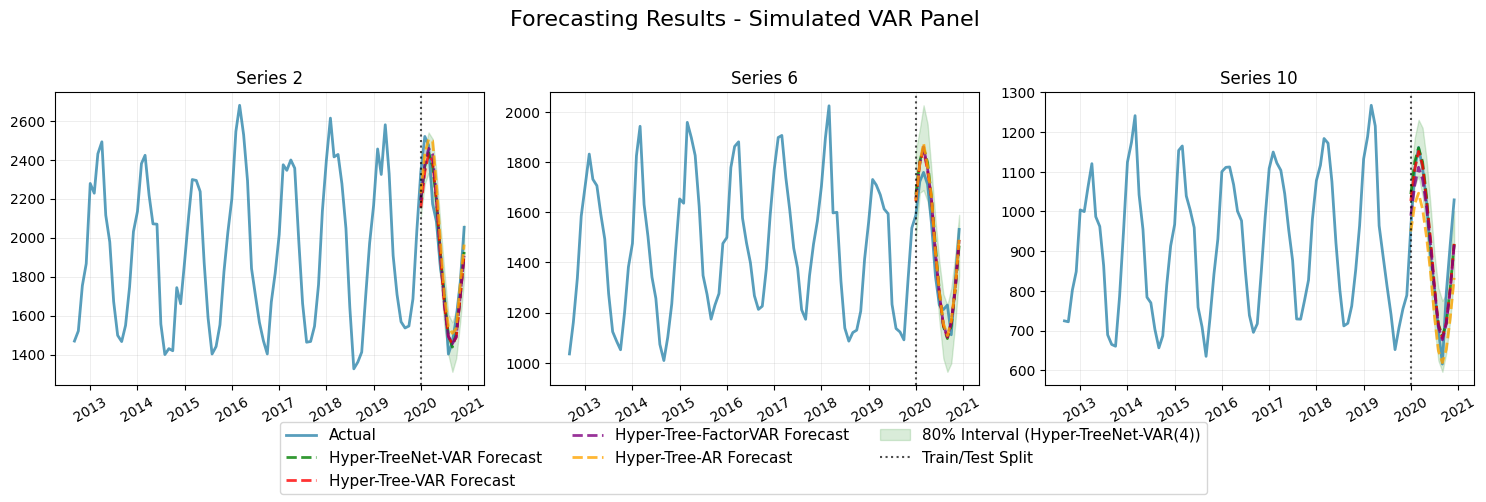

In [7]:
datasets = [
    (df, "date", "value", "Actual", "#2E86AB", "-"),
    (htnet_var_fcst, "date", "fcst", "Hyper-TreeNet-VAR Forecast", "green", "--"),
    (ht_var_fcst, "date", "fcst", "Hyper-Tree-VAR Forecast", "red", "--"),
    (ht_factor_var_fcst, "date", "fcst", "Hyper-Tree-FactorVAR Forecast", "purple", "--"),
    (ht_ar_fcst, "date", "fcst", "Hyper-Tree-AR Forecast", "orange", "--"),
]

plot_panel_forecasts(
    datasets,
    series_ids=["Series 2", "Series 6", "Series 10"],
    split_date=test["date"].min(),
    interval_fcst=htnet_var_fcst,
    level=level[0],
)

## Inspecting the Time-Varying Coefficients

`forecast(type="parameters")` returns every VAR coefficient as a column. A VAR(p) is conventionally written as

$$y_t = A_1 y_{t-1} + A_2 y_{t-2} + \dots + A_p y_{t-p}$$

so with `var_p = 4` there are four coefficient matrices `A1, ..., A4` (one per lag), each of size k x k, where k is the number of series in the panel (here `k = 10`). Each DataFrame row holds the equation of its `series_id`, i.e. one row of every lag matrix, which is why a row carries `k * var_p = 40` coefficient columns. Reading a cell:

- the row's `series_id` selects **which equation** (the matrix row: the series being forecast),
- `A{j}` selects **which lag** (the j-th matrix, j months back),
- `(Series m)` selects **which source series** the coefficient multiplies (the matrix column).

Below we look at the equation of Series 6: `A1(Series 6)` and `A2(Series 6)` are its own-lag effects (the multivariate analog of the `AR(1), ..., AR(p)` columns of `HyperTreeAR`), while `A1(Series 5)` is the weight that Series 5's previous month receives in Series 6's forecast. In the simulation that is exactly the lead/lag link (Series 6 is driven by Series 5), and `A1(Series 1)` is an unrelated series for comparison. Stacking the k rows that share a date recovers the complete time-varying matrices for that time step. Note that the coefficients live in the scaled space (per-series scaling).

In [8]:
params = htnet_var.forecast(test_data=test, type="parameters")
params[params["series_id"] == "Series 6"][["date", "A1(Series 6)", "A1(Series 5)", "A2(Series 6)", "A1(Series 1)"]].head()

,date,A1(Series 6),A1(Series 5),A2(Series 6),A1(Series 1)
60,2020-01-01,0.045522,0.026507,0.056337,0.020276
61,2020-02-01,0.043268,0.027609,0.052135,0.022095
62,2020-03-01,0.037825,0.030270,0.041986,0.026486
63,2020-04-01,0.030708,0.033750,0.028717,0.032228
64,2020-05-01,0.023783,0.037752,0.015588,0.037502


## Accuracy Comparison

On data with genuine cross-series structure, the VAR models should come out ahead of the univariate baseline.

In [9]:
fcsts_df = pd.concat(
    [
        htnet_var_fcst,
        ht_var_fcst,
        ht_factor_var_fcst,
        ht_ar_fcst,
    ], axis=0).merge(
    test[["series_id", "date", "value"]],
    on=["series_id", "date"],
    how="inner"
)

fcsts_df.groupby("model")[["value", "fcst"]].apply(calculate_metrics).round(3)

,MAE,MAPE,sMAPE,WAPE,RMSE
model,,,,,
Hyper-Tree-AR(4),65.788,6.350,6.403,5.797,85.259
Hyper-Tree-FactorVAR(4),57.622,5.107,5.138,5.077,74.867
Hyper-Tree-VAR(4),56.078,4.893,4.928,4.941,73.982
Hyper-TreeNet-VAR(4),55.059,4.831,4.842,4.851,71.324


## Practical Notes

- **Aligned panel required**: all series must have the same length and identical dates, because the VAR design vector stacks the lags of every series at the same time points.
- **Series identity feature**: include one (like `series_num` above) so the global GBDT can produce equation-specific coefficients, and cast it to pandas `category` dtype for true categorical splits.
- **Scaling**: per-series mean scaling is on by default (`scaling="mean"`). VAR coefficients multiply *other* series' values, so unscaled heterogeneous panels force the model to learn scale conversions while the loss is dominated by the largest series. `"standard"` and `None` are also available.
- **Which model**: prefer `HyperTreeNetVAR`. Use the direct `HyperTreeVAR` for small panels where coefficient-level interpretability matters, or `type="factor"` when the panel is large and cross-series dynamics plausibly run through a common factor rather than dense pairwise links.
- **When to prefer the univariate AR instead**: if your series do not genuinely lead or lag each other, a VAR pays a large estimation-variance bill (`k * p` coefficients per equation) for little information gain.